- database for gene co-expression: https://coxpresdb.jp/gene_coexpression/?gene_id=7535&dataset=17
- topic modeling: https://github.com/gregversteeg/corex_topic/blob/master/corextopic/example/corex_topic_example.ipynb 

1.	PI3K/AKT/mTOR: Increase
2.	mTORC1: Increase
3.	P53: Increase
4.	TNF-α/NF-κB: Increase
5.	TGF-β: Increase
6.	WNT/β-Catenin: Dysregulated
7.	Oxidative Phosphorylation (OXPHOS): Decrease


### robustness 
- we included only genes that are exressed across all age groups. there could be a scenario where there is high expression of a particular genes for an age group
- normalization technique 
- corr method 
- subsampling 



# Imports

In [7]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from statsmodels.stats.multitest import multipletests


from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func


%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

par = {
    'input_dir': 'input/',
    'age_groups': ['34-', '35_44', '45_54', '55_64', '65_75']
    }

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Create a DataFrame for pathway annotations
pathway_assignments = []
for pathway, genes in genesets_dict.items():
    for gene in genes:
        pathway_assignments.append((gene, pathway))

pathway_df = pd.DataFrame(pathway_assignments, columns=['gene', 'pathway']).set_index('gene')


df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
housekeeping_genes = set(df.loc[:, 0])

# Correlation analysis

In [175]:
if False: # calculate correlations
    calculate_coexp_all(adata_dir='input/adata.h5ad', normalize='lognorm', corr_method='spearman', write_file='output/coexp_adata_sla_spearman.h5ad')

In [71]:
if True:
    import subprocess
    from itertools import product

    # Example usage
    normalize_options = ['sla', 'apr']  # Replace with actual normalization options
    corr_method_options = ['pearson', 'spearman']  # Replace with actual correlation methods
    denoise_options = [True, False]  # Boolean argument options

    i_job = 0
    for normalize, corr_method, denoise in product(normalize_options, corr_method_options, denoise_options):
        # Prepare the sbatch command with arguments
        sbatch_command = [
            "sbatch",
            f"--job-name=coexp_analysis_{i_job}",
            "--output=logs/output_%j.log",
            "--error=logs/error_%j.log",
            "--time=02:00:00",
            "--cpus-per-task=4",
            "--mem=250G",
            "--partition=gpu",
            f"scripts/sbatch/corr_analysis.sh",
            f"{normalize}",
            f"{corr_method}",
        ]
        # sbatch_command = [
        #     "bash",
        #     f"scripts/sbatch/corr_analysis.sh",
        #     f"{normalize}",
        #     f"{corr_method}",
        # ]
        if denoise:
            sbatch_command += ['denoise']

        # Submit the job
        print(f"Submitting job with normalize={normalize}, corr_method={corr_method}, denoise={denoise}")
        subprocess.run(sbatch_command)
        i_job+=1
        

    


Submitting job with normalize=sla, corr_method=pearson, denoise=True
Submitted batch job 7788357
Submitting job with normalize=sla, corr_method=pearson, denoise=False
Submitted batch job 7788358
Submitting job with normalize=sla, corr_method=spearman, denoise=True
Submitted batch job 7788359
Submitting job with normalize=sla, corr_method=spearman, denoise=False
Submitted batch job 7788360
Submitting job with normalize=apr, corr_method=pearson, denoise=True
Submitted batch job 7788361
Submitting job with normalize=apr, corr_method=pearson, denoise=False
Submitted batch job 7788362
Submitting job with normalize=apr, corr_method=spearman, denoise=True
Submitted batch job 7788363
Submitting job with normalize=apr, corr_method=spearman, denoise=False
Submitted batch job 7788364


 39%|███▉      | 19/49 [04:47<08:01, 16.06s/it]

shape before  (4000, 891)
shape after  (4000, 885)


In [62]:
!ls scripts/sbatch/

corr_analysis.sh  sbatch.py  scgen.sh  scvi.py


# PCA analysis across ages

In [3]:
if False: 
    coexp_adata = ad.read_h5ad('output/coexp_adata_apr_spearman_bootstrapped_denoised.h5ad')
    coexp_adata.obs.age_group = coexp_adata.obs.age_group.replace('-34', '34-')
    coexp_adata.obs.age_group = coexp_adata.obs.age_group.astype('str').astype('category')
    print(coexp_adata)

    # - keep only that are present in all 
    mask_zeros = (coexp_adata.X==0).any(axis=0)
    coexp_adata = coexp_adata[:, ~mask_zeros]
    print(coexp_adata)
    print(coexp_adata.obs.nunique())
    # - make a df 
    coexp_df = pd.DataFrame(coexp_adata.X, columns=coexp_adata.var_names, index=pd.MultiIndex.from_frame(coexp_adata.obs, names=coexp_adata.obs.columns))

    coexp_long_df = coexp_df.reset_index(level=['batch_group', 'age_group', 'age_donor']).melt(id_vars=['batch_group', 'age_group', 'age_donor'], var_name='link', value_name='weight')
    coexp_long_df.head()

    if True: # testing group difference for different pcs
        sc.pp.pca(coexp_adata)

        data_store = []
        for pca_i in [0, 1, 2, 4, 5, 6]:
            for age_group in coexp_adata.obs.age_group.unique():
                mask_control = coexp_adata.obs.age_group != age_group
                mask_sample = coexp_adata.obs.age_group == age_group
                ctr_pca = coexp_adata[mask_control, :].obsm['X_pca'][:, pca_i]
                ctr_sample = coexp_adata[mask_sample, :].obsm['X_pca'][:, pca_i]

                data = {'age_group':age_group, 'PCA': pca_i, 'pvalue': stats.mannwhitneyu(ctr_pca, ctr_sample)[1]}
                data_store.append(data)
        df_pca_pvalues = pd.DataFrame(data_store)

        print(df_pca_pvalues.pivot(index='age_group', columns='PCA', values='pvalue'))

        # -- which links are connected to pca 2
        pc2_loadings = pd.DataFrame({'share':coexp_adata.varm['PCs'][:, 1]}, index= coexp_adata.var_names)
        pc2_loadings = pc2_loadings.sort_values(by='share', ascending=False, key=abs)[:500]

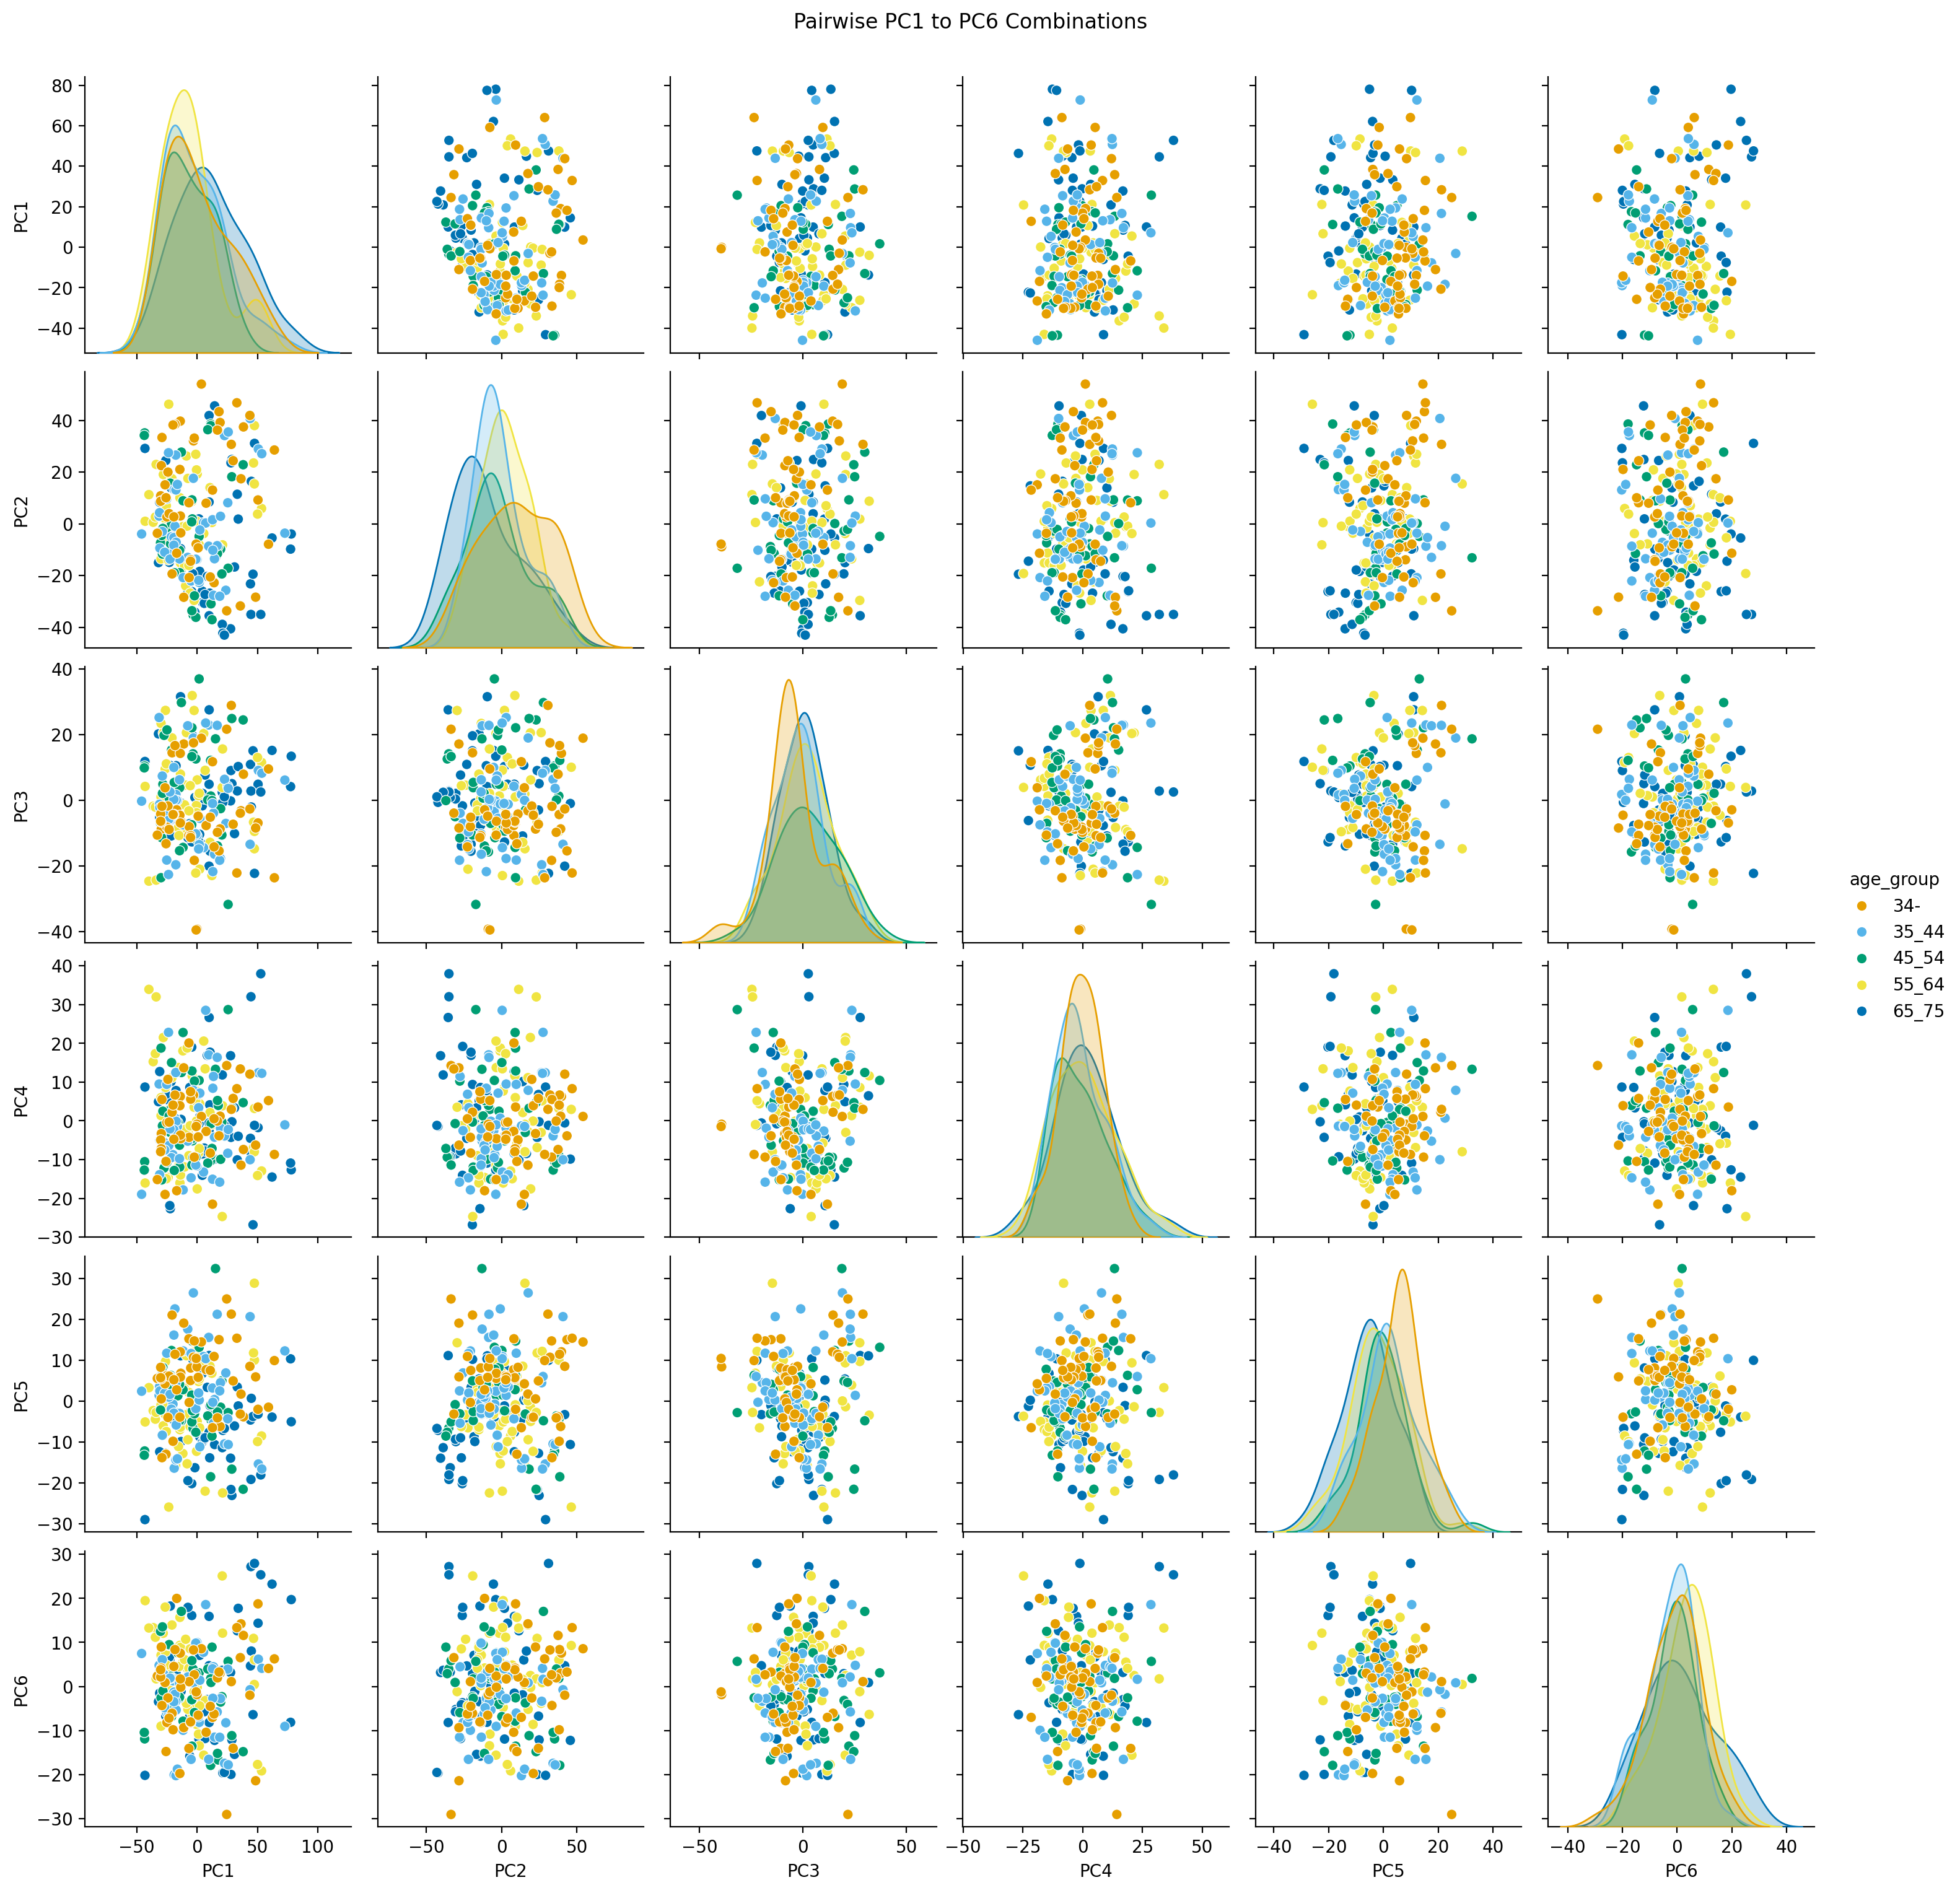

In [3]:
pca_df = pd.DataFrame(coexp_adata.obsm['X_pca'][:, :6], columns=[f'PC{i+1}' for i in range(6)])

# Add age_group to the DataFrame
pca_df['age_group'] = coexp_adata.obs['age_group'].values
# Create pairplot of all combinations of PC1 to PC6, colored by age_group
sns.pairplot(pca_df, hue='age_group', palette=colors_blind)  # You can choose any palette you prefer
plt.suptitle("Pairwise PC1 to PC6 Combinations", y=1.02)
plt.show()

In [4]:
# obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)
# obs

In [14]:
coexp_adata.obs[['age','donor_id','sample']] = coexp_adata.obs.age_donor.str.split('_', expand=True)

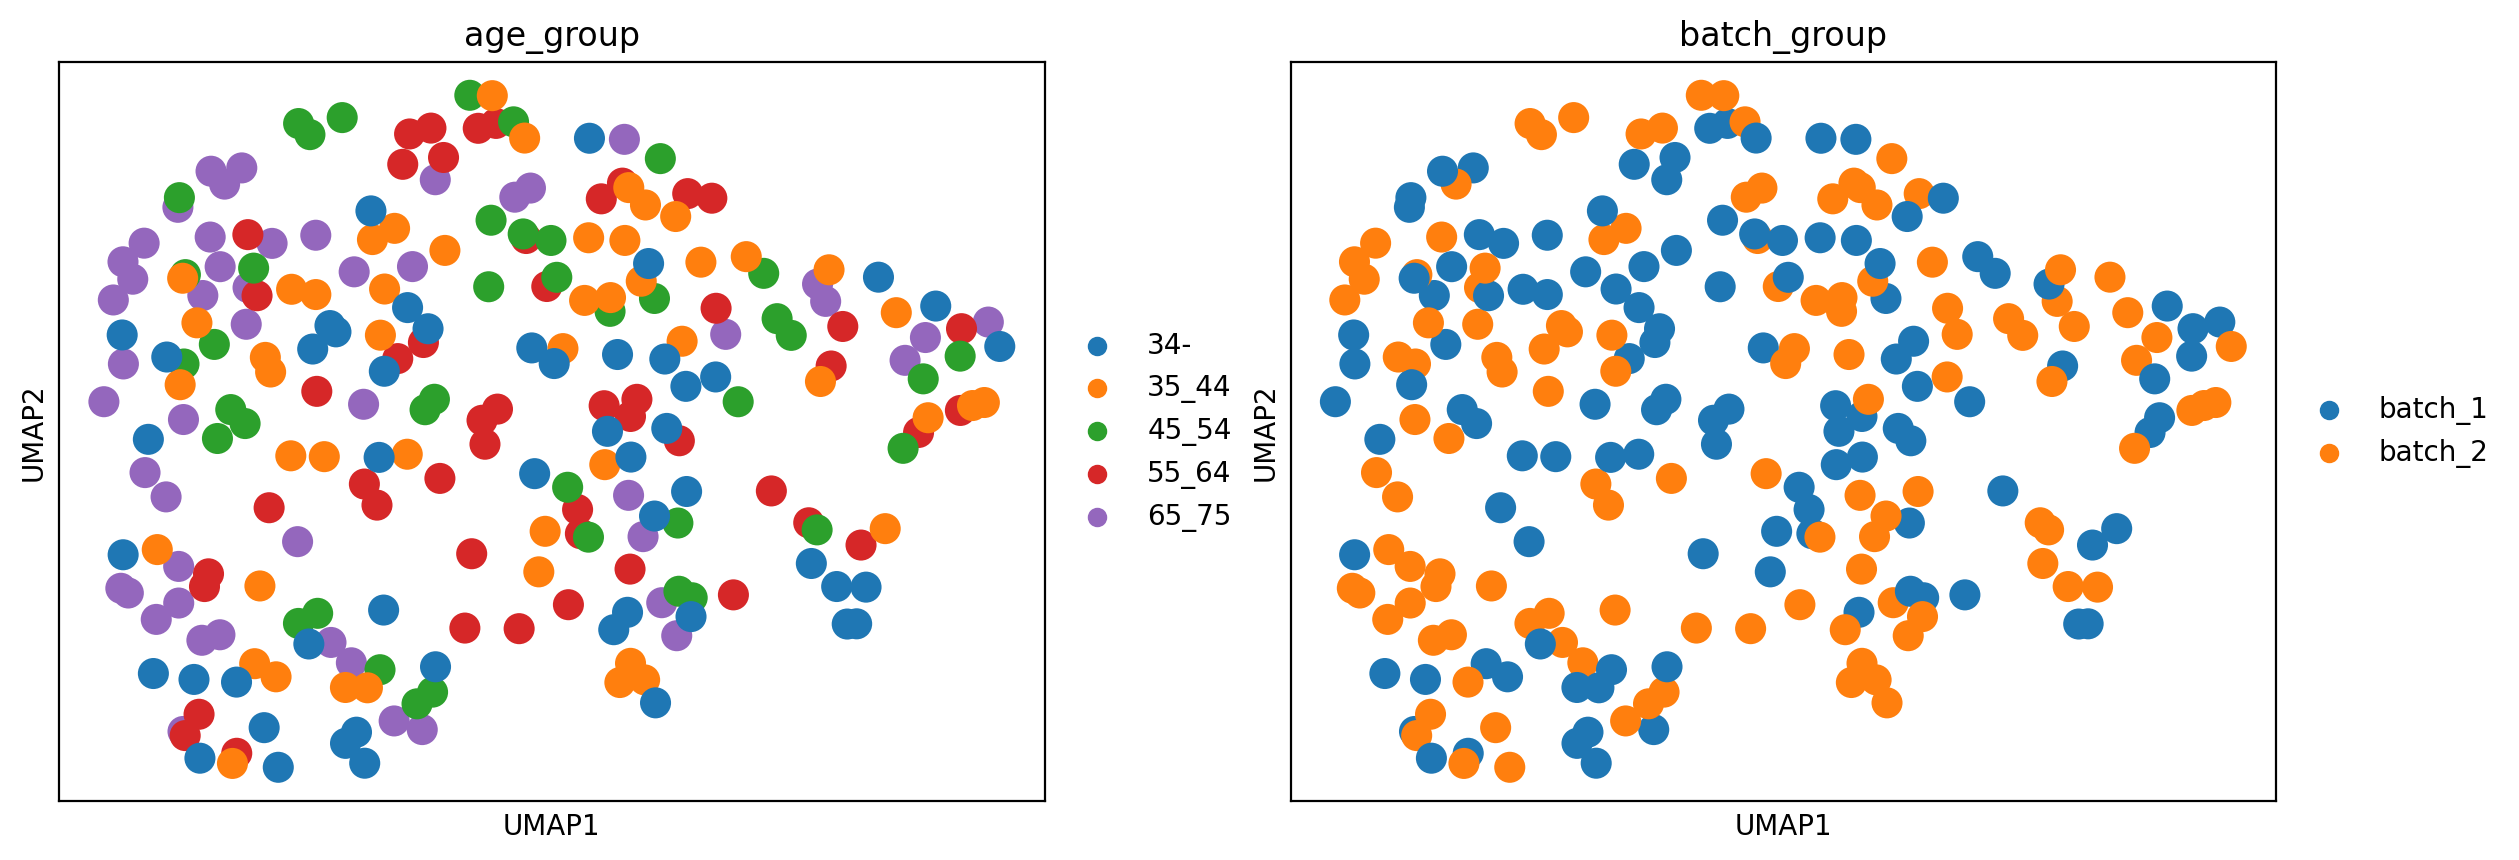

In [6]:
# Compute UMAP after PCA
sc.pp.neighbors(coexp_adata, n_pcs=10)
sc.tl.umap(coexp_adata)

# Plot UMAP
sc.pl.umap(coexp_adata, color=['age_group', 'batch_group'])  # or use any category in `obs`

In [116]:
if False: # headmap association of loadings to pcs
    # lets plot heatmap
    df = pc2_loadings.reset_index()
    df['weight'] = df.share

    g_g_matrix = link_to_matrix(df)
    heatmap_pathways(g_g_matrix, pathway_df)

# Geneset specific distribution

In [6]:
if False: # violin plot for each geneset. p values are calculcated per group
    def do_violin(adata, ax):
        corr_df = pd.DataFrame(adata.X, columns=adata.var_names)
        corr_df['age_group'] = adata.obs['age_group'].values
        corr_long = corr_df.melt(id_vars=['age_group'], var_name='link', value_name='correlation')
        reference_group = corr_long[corr_long['age_group'] == '34-']
        other_groups = corr_long[corr_long['age_group'] != '34-']

        p_values = {}

        # Perform Mann-Whitney U test between reference group and each other group
        for age_group in other_groups['age_group'].unique():
            group_corr = other_groups[other_groups['age_group'] == age_group]['correlation']
            ref_corr = reference_group['correlation']
            u_stat, p_value = stats.mannwhitneyu(ref_corr, group_corr)
            p_values[age_group] = p_value

        sns.violinplot(x='age_group', y='correlation', data=corr_long, ax=ax)

        ax.set_ylim([-1.1,1.1])

        for i, age_group in enumerate(other_groups['age_group'].unique()):
            ax.text(i+1, .9, f'{p_values[age_group]:.3f}', ha='center', va='bottom', color='black')

    # - geneset specific data 
    genesets = get_genesets()
    coexp_adata = ad.read_h5ad('output/coexp_adata_apr_spearman_bootstrapped_denoised.h5ad')

    for i , (name, geneset) in enumerate(genesets.items()):
        fig, axes = plt.subplots(1, 2, figsize=(8, 3))
        for i_batch, batch in enumerate(['batch_1', 'batch_2']):
            ax = axes[i_batch]
            adata_b = coexp_adata[coexp_adata.obs.batch_group == batch]
        
            geneset_links = ['_'.join(sorted(combination)) for combination in list(itertools.combinations(geneset,2))]
            adata_b_g = adata_b[:, adata_b.var_names.isin(geneset_links)]
            do_violin(adata_b_g, ax)

            ax.set_title(f'{name}-{batch}')
        plt.tight_layout()        

# Edge: sig versus 34-

In [4]:
if False: # run sig test
    sig_test_all(coexp_adata_file='output/coexp_adata_apr_spearman.h5ad', ctr_group='34-', col_contrast='age_group', col_link='link', save_file='output/links_pvalues_vs_34.csv')

100%|██████████| 375411/375411 [46:20<00:00, 134.99it/s]


In [52]:
# - shared links across batches 
contrast_results_dict = {
    'links_pvalues_vs_34_sla_spearman_bootstrapped': pd.read_csv('output/links_pvalues_vs_34_sla_spearman_bootstrapped.csv', index_col=0),
    'links_pvalues_vs_34_apr_pearson_bootstrapped': pd.read_csv('output/links_pvalues_vs_34_apr_pearson_bootstrapped.csv', index_col=0),

}

i = 0
for key, df in contrast_results_dict.items():
    
    df['bonferroni'] = multipletests(df['pvalue'], alpha=0.05, method='bonferroni')[1]
    df['fdr'] = multipletests(df['pvalue'], alpha=0.05, method='fdr_bh')[1]

    # - add sig column 
    # mask = (df['pvalue']<0.001) & (df['mean'].abs()>0.1)
    # mask = (df['fdr']<0.05) & (df['diff'].abs()>0.1) & ((df['mean'].abs()>0.05)|(df['mean_ctr'].abs()>0.05))
    mask = df['bonferroni']<0.05

    df = df[mask]
    df['model'] = key
    if i == 0:
        sig_results = df
    else:
        sig_results = pd.concat([df, sig_results], axis=0)
    i+=1

# - common sig links across different methods
n_methods = sig_results.model.nunique()
df = (sig_results.groupby(['link', 'age_group']).size()==n_methods).reset_index(name='sig_common')
sig_results = sig_results.merge(df, on=['link', 'age_group'], how='left')
common_links_df = sig_results[sig_results['sig_common']]

# - add data of each method in the format of method-tag and mean across all
def merge_cols(df):
    # take mean corr
    # df_mean = df.groupby(['link', 'age_group'])['mean'].mean().reset_index(name='mean')
    # pivot to get model specific columns
    df_pivot = df.pivot_table(
        index=['link', 'age_group'],  
        columns='model',              
        values=['mean', 'mean_ctr', 'diff'] 
    )
    df_pivot.columns = ['{}-{}'.format(model, item) for item, model in df_pivot.columns]
    # merge mean with model specific info
    df_pivot = df_pivot.reset_index()
    # df_pivot = df_pivot.merge(df_mean, on=['link', 'age_group'])

    return  df_pivot

common_links_df = merge_cols(common_links_df)

# - add mean corr across all methods
cols_mean = [f'{method}-mean' for method in contrast_results_dict.keys()]
common_links_df['mean'] = common_links_df[cols_mean].mean(axis=1)
common_links_df

,link,age_group,links_pvalues_vs_34_apr_pearson_bootstrapped-diff,links_pvalues_vs_34_sla_spearman_bootstrapped-diff,links_pvalues_vs_34_apr_pearson_bootstrapped-mean,links_pvalues_vs_34_sla_spearman_bootstrapped-mean,links_pvalues_vs_34_apr_pearson_bootstrapped-mean_ctr,links_pvalues_vs_34_sla_spearman_bootstrapped-mean_ctr,mean
0,ADGRG1_ALDOA,65_75,-0.043029,-0.046752,-0.080353,-0.068084,-0.037324,-0.021332,-0.074218
1,ALDOA_XBP1,65_75,-0.047532,-0.038614,-0.078240,-0.034486,-0.030708,0.004128,-0.056363
2,ATP5MG_GAPDH,65_75,0.056633,0.047711,0.054412,0.038840,-0.002221,-0.008871,0.046626
3,ATP5MG_LEF1,65_75,-0.047663,-0.048594,0.068040,0.072971,0.115704,0.121565,0.070506
4,ATP5MG_S100A4,65_75,0.069797,0.071592,0.004077,-0.002198,-0.065719,-0.073791,0.000940
...,...,...,...,...,...,...,...,...,...
122,S100A4_SLC25A3,65_75,0.053486,0.059260,0.022659,0.027420,-0.030827,-0.031840,0.025039
123,S100A4_TRGV9,65_75,-0.067701,-0.078868,-0.028792,0.024116,0.038909,0.102984,-0.002338
124,S100A4_UQCRB,65_75,0.057515,0.061234,-0.125436,-0.126330,-0.182950,-0.187565,-0.125883
125,S100A4_XBP1,65_75,-0.098163,-0.102113,-0.095695,-0.028850,0.002468,0.073263,-0.062273


In [16]:
common_links_df.age_group.value_counts()

age_group
65_75    546
45_54      7
55_64      2
Name: count, dtype: int64

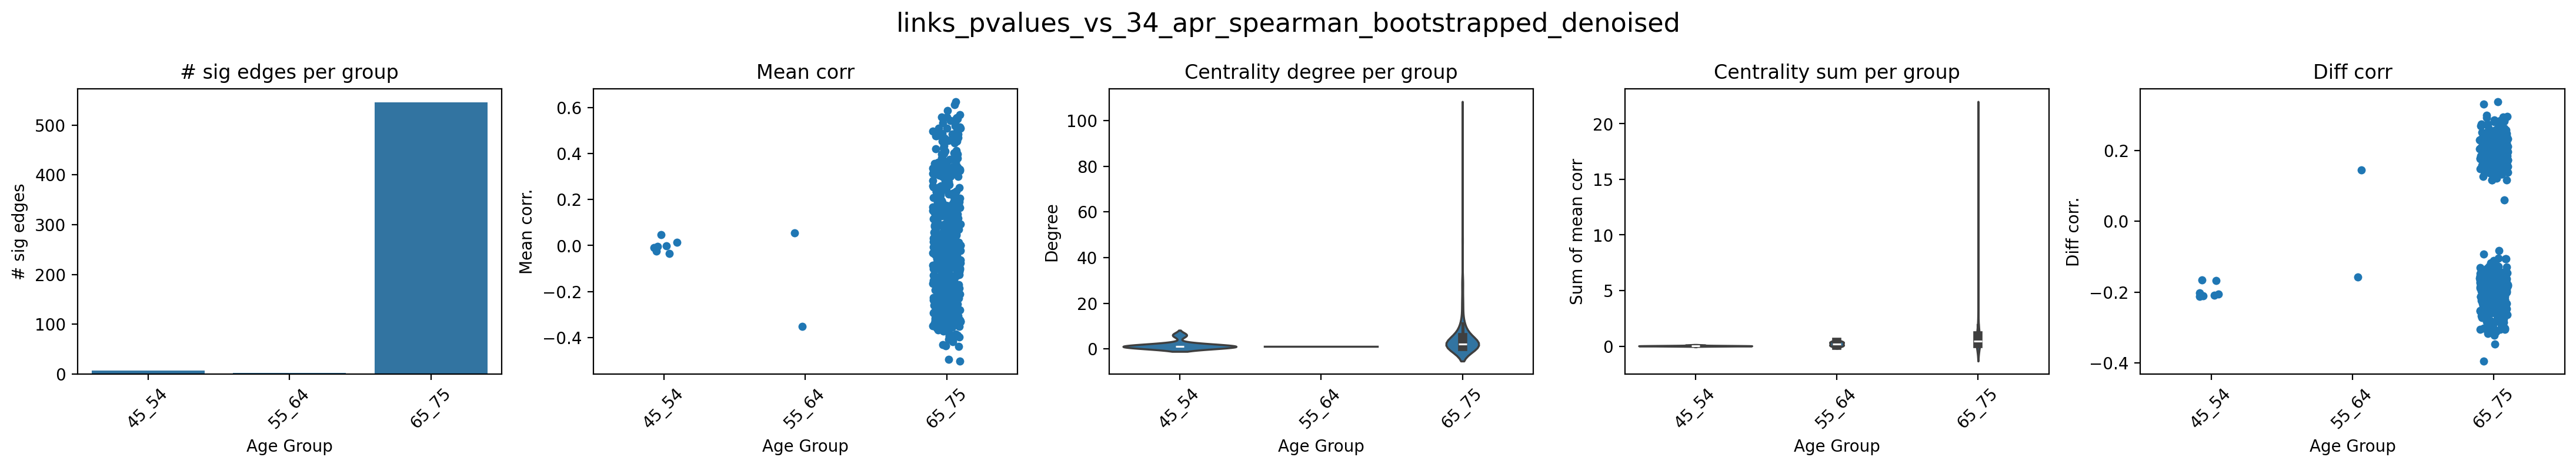

In [17]:
# - plot dist of number of sig links
def plot_exp(groups, suptitle):
    def deg_cent(df):
        df['weight'] = 1
        gg_mat = link_to_matrix(df)
        degree = gg_mat.sum()
        return degree
    def sum_cent(df):
        df['weight'] = df['mean']
        gg_mat = link_to_matrix(df)
        sum_mean = gg_mat.abs().sum()
        return sum_mean

    n_sig_edges = groups.size().reset_index(name='# sig edges')
    mean_corr = groups.apply(lambda df: df['mean']).reset_index(name='mean_corr')
    diff_corr = groups.apply(lambda df: df['diff']).reset_index(name='diff_corr')
    cent_degree = groups.apply(deg_cent).reset_index(name='degree')
    cent_sum = groups.apply(sum_cent).reset_index(name='sum_mean')
    

    # Create subplots
    fig, axes = plt.subplots(1, 5, figsize=(22, 4), gridspec_kw={'width_ratios':[1, 1, 1, 1, 1]})

    # Plot # of edges
    sns.barplot(data=n_sig_edges, x='age_group', y='# sig edges',ax=axes[0])
    axes[0].set_title('# sig edges per group')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel('# sig edges')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot mean corr for each group
    ax = axes[1]
    sns.stripplot(data=mean_corr, x='age_group', y='mean_corr',ax=ax)
    ax.set_title('Mean corr')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Mean corr.')
    ax.tick_params(axis='x', rotation=45)

    # Plot diff corr for each group
    ax = axes[4]
    sns.stripplot(data=diff_corr, x='age_group', y='diff_corr',ax=ax)
    ax.set_title('Diff corr')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Diff corr.')
    ax.tick_params(axis='x', rotation=45)


    # Plot distribution of centrality degree
    ax = axes[2]
    sns.violinplot(data=cent_degree, x='age_group', y='degree',ax=ax)
    ax.set_title('Centrality degree per group')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Degree')
    ax.tick_params(axis='x', rotation=45)

    # Plot distribution of centrality sum
    ax = axes[3]
    sns.violinplot(data=cent_sum, x='age_group', y='sum_mean',ax=ax)
    ax.set_title('Centrality sum per group')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Sum of mean corr')
    ax.tick_params(axis='x', rotation=45)


    fig.suptitle(suptitle, fontsize=16)

    # Adjust layout
    plt.tight_layout()
    
for model in sig_results.model.unique():
    df = sig_results[sig_results.model==model]
    groups = df.groupby('age_group')
    plot_exp(groups, model)
    

['links_pvalues_vs_34_sla_spearman_bootstrapped', 'links_pvalues_vs_34_apr_pearson_bootstrapped']
['links_pvalues_vs_34_apr_pearson_bootstrapped', 'links_pvalues_vs_34_sla_spearman_bootstrapped']


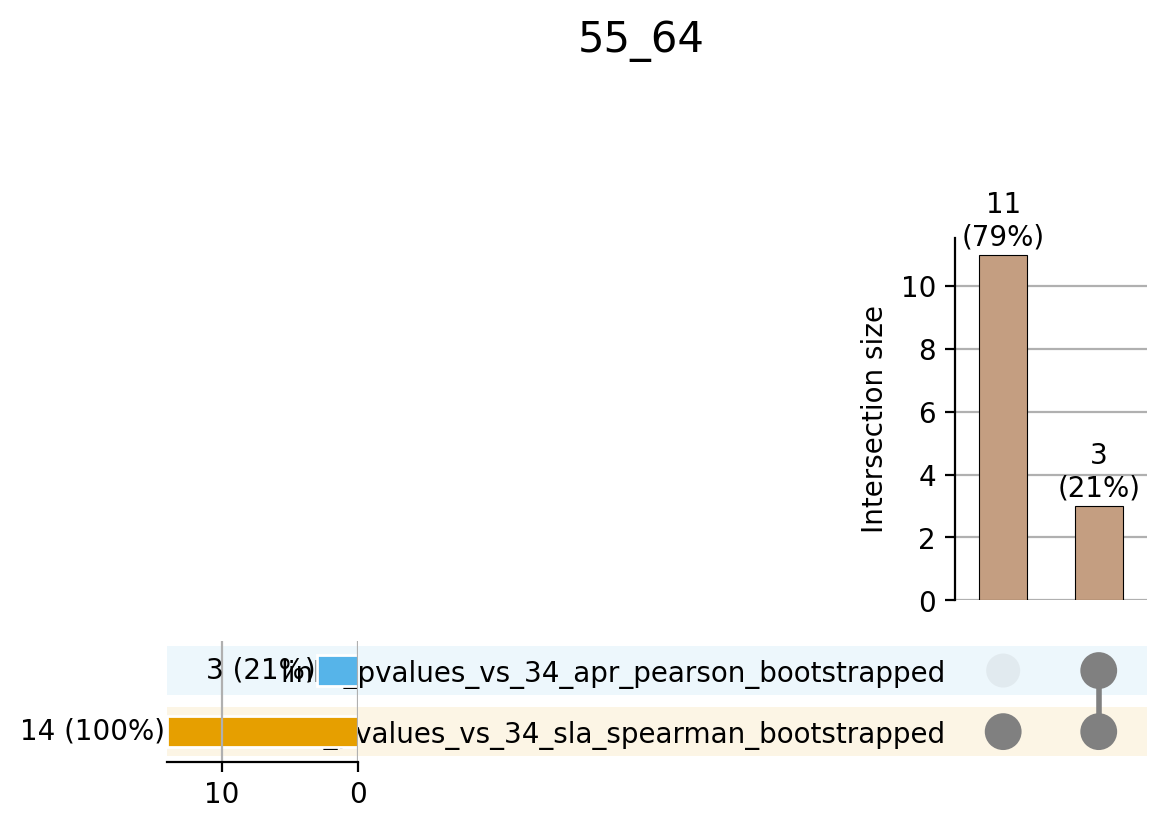

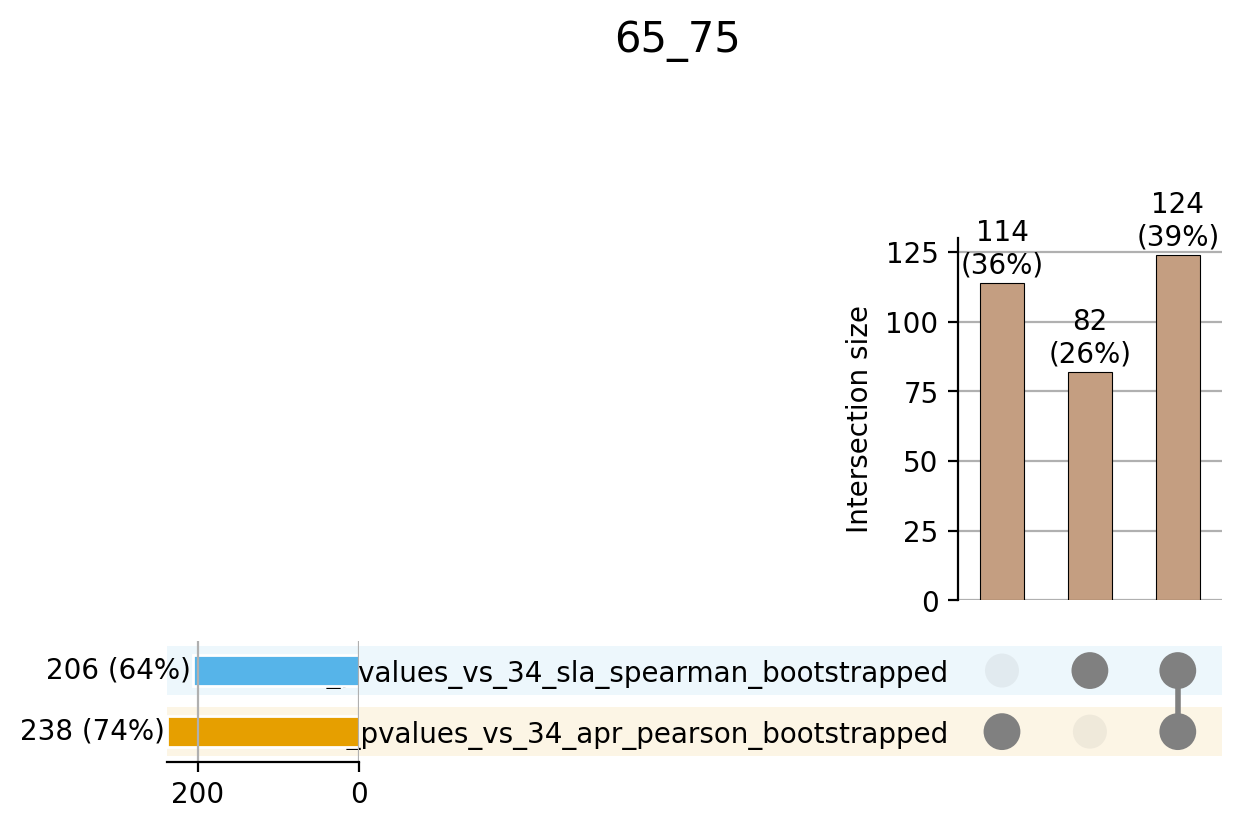

In [54]:
if True: # intersection of sig links across models: age specific 
    # for age_group in ['35_44', '45_54', '55_64', '65_75']:
    for age_group in ['55_64', '65_75']:
        sig_results_a = sig_results[sig_results.age_group==age_group]
        
        # plot intersection
        links_dict = sig_results_a.groupby('model').apply(lambda df: df['link'].values).to_dict()
        interaction_df = create_interaction_df(links_dict)
        fig = plot_interactions(interaction_df, min_subset_size=1, min_degree=1, sort_by='degree')
        fig.suptitle(age_group, fontsize=15, y=1.2)

In [127]:
if False: #joint plot of different methods
    tag = 'mean'

    def plot_join(method1, method2):
        sns.jointplot(
            data = common_links_df, 
            x = f"{method1}-{tag}", 
            y = f"{method2}-{tag}", 
            hue="age_group",   # Color points by "True"/"False"
            # kind="kde",    # Contours with kde
            # fill=False,    # Fill contour lines
            marginal_kws=dict(common_norm=False, fill=True),  # Marginal distribution,
            alpha=.5
        )
        plt.xlabel(method1)
        plt.ylabel(method2)
        plt.suptitle(tag, fontsize=20, y=1.1)
    models = list(contrast_results_dict.keys())
    plot_join(models[0], models[1])
    # plot_join('sla_pearson', 'apr_pearson')

In [128]:
if False: # intersection of sig links for age groups
    df_sig = common_links_df
    groups = df_sig.groupby('age_group')
    
    interaction_df = create_interaction_df(groups.apply(lambda df: df['link'].values).to_dict())
    fig = plot_interactions(interaction_df, min_subset_size=1, min_degree=1, sort_by='degree')

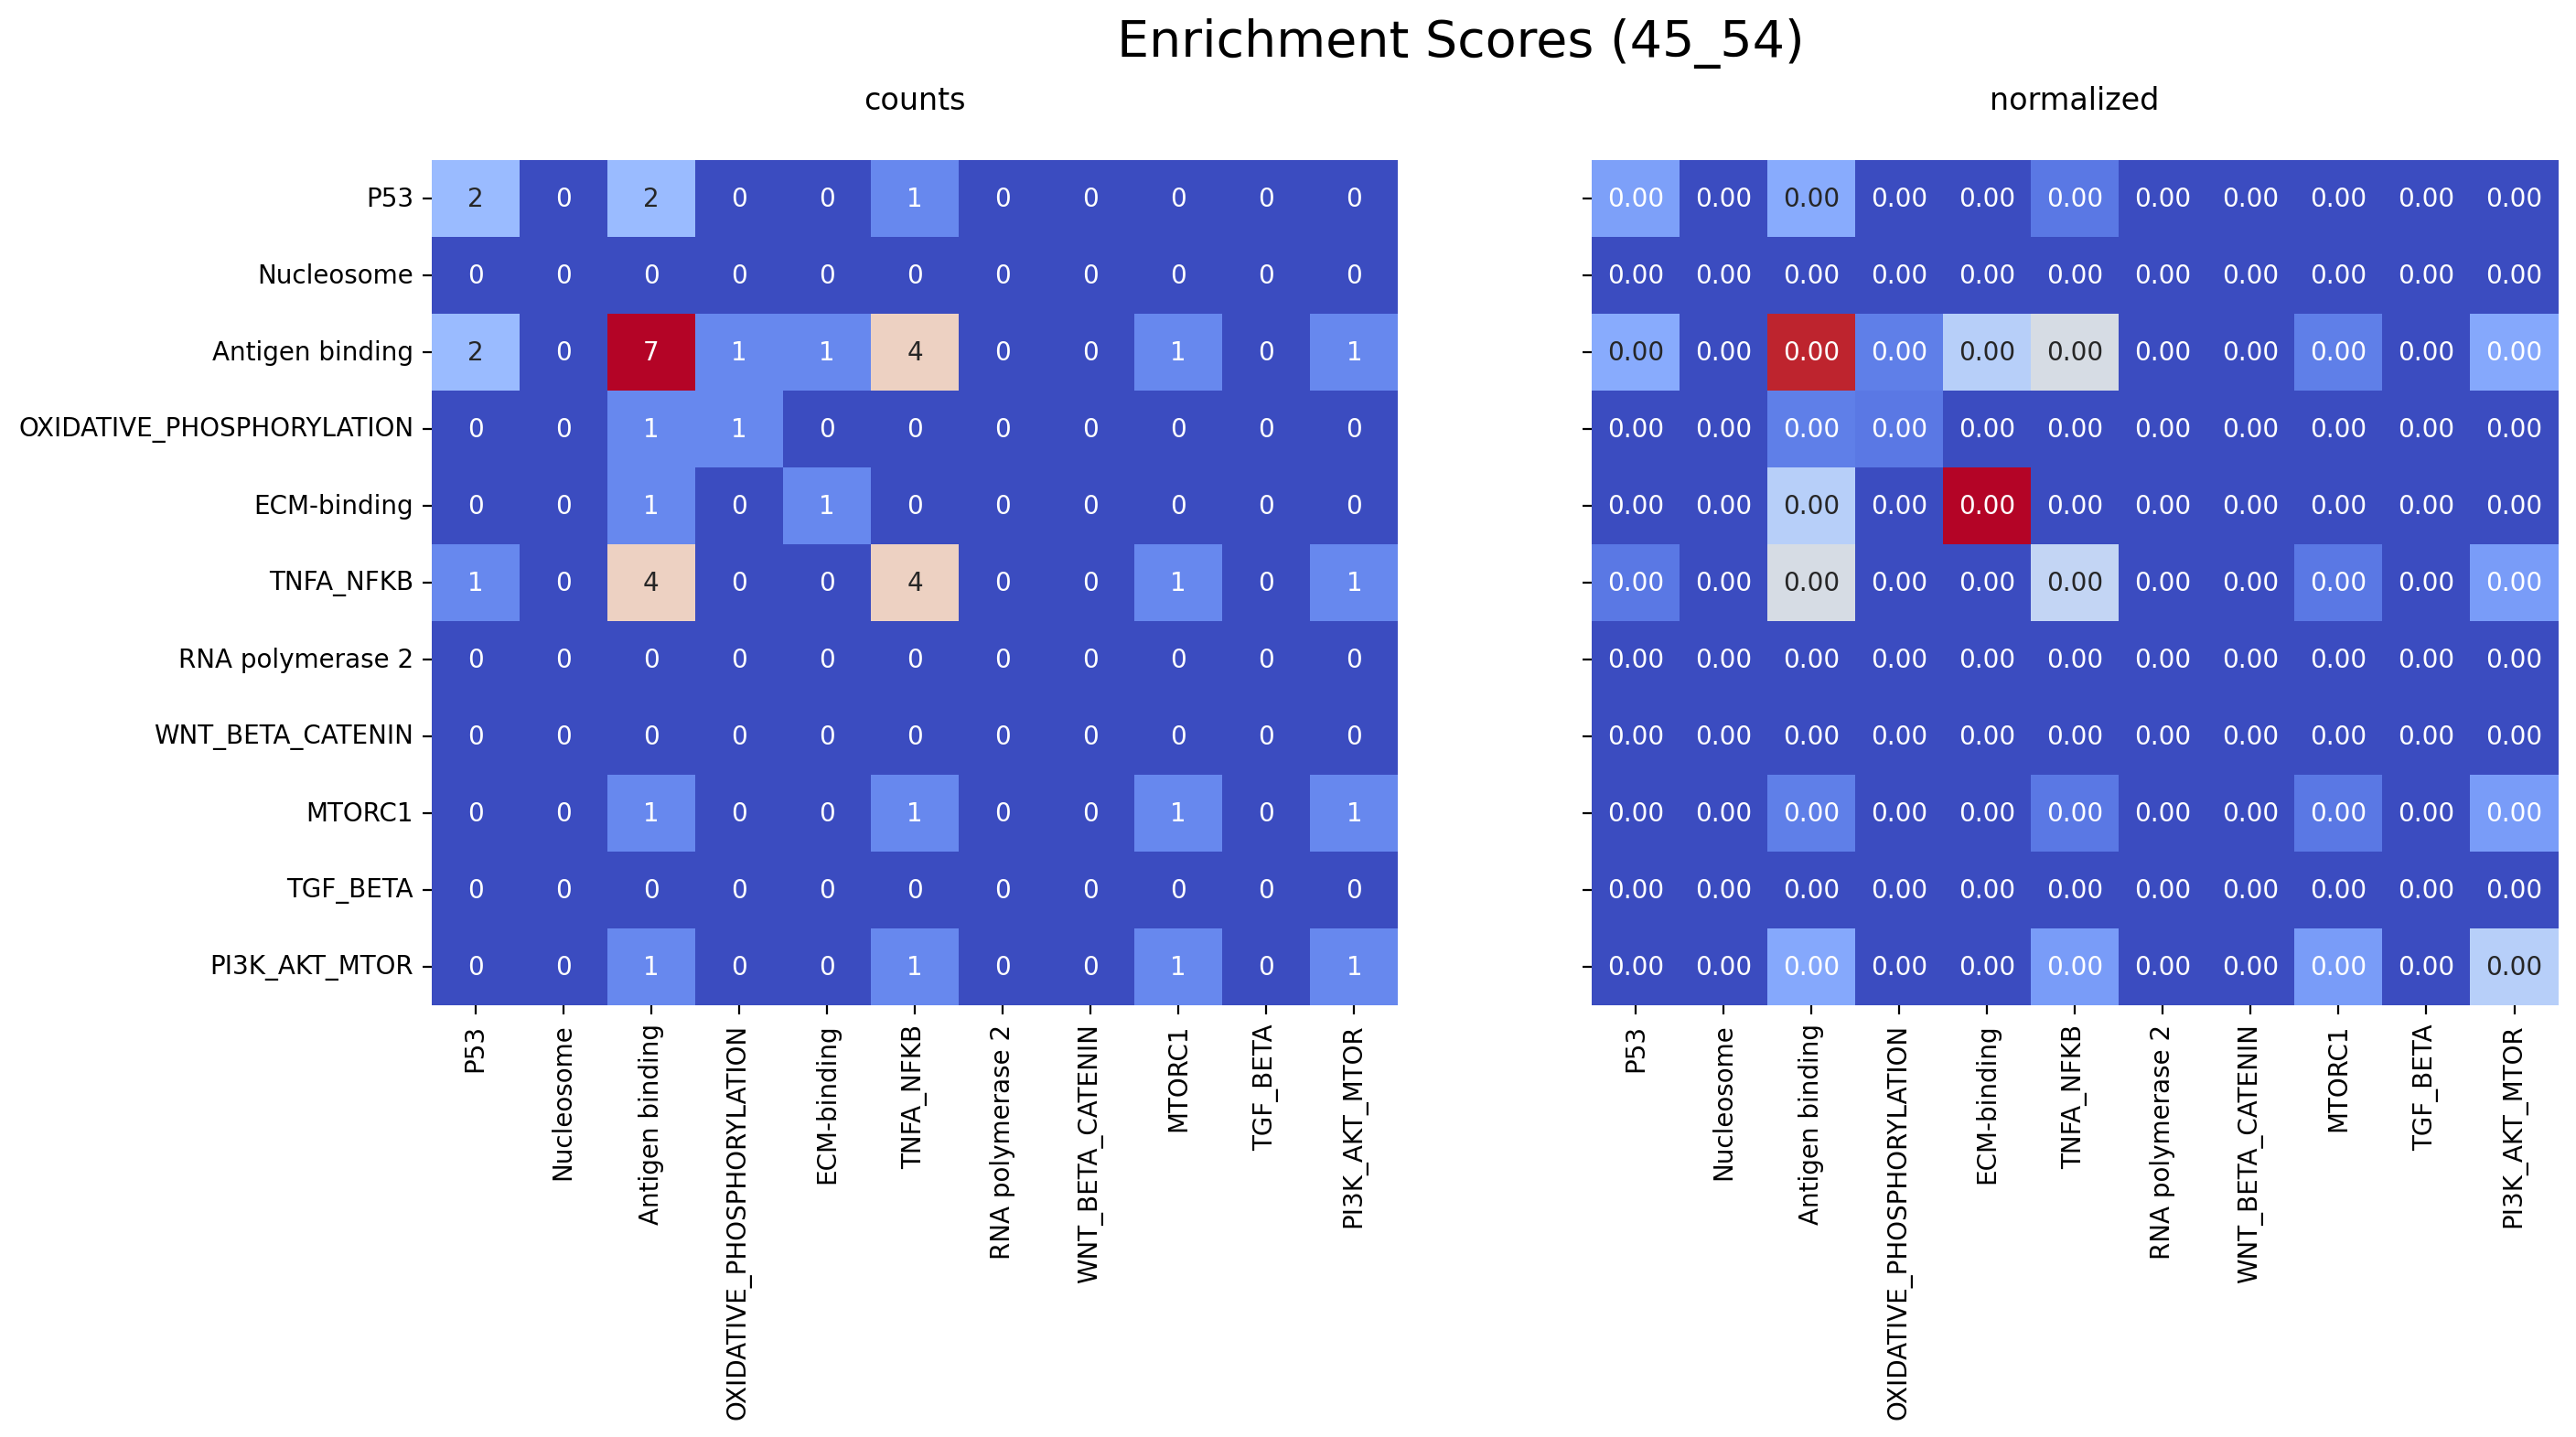

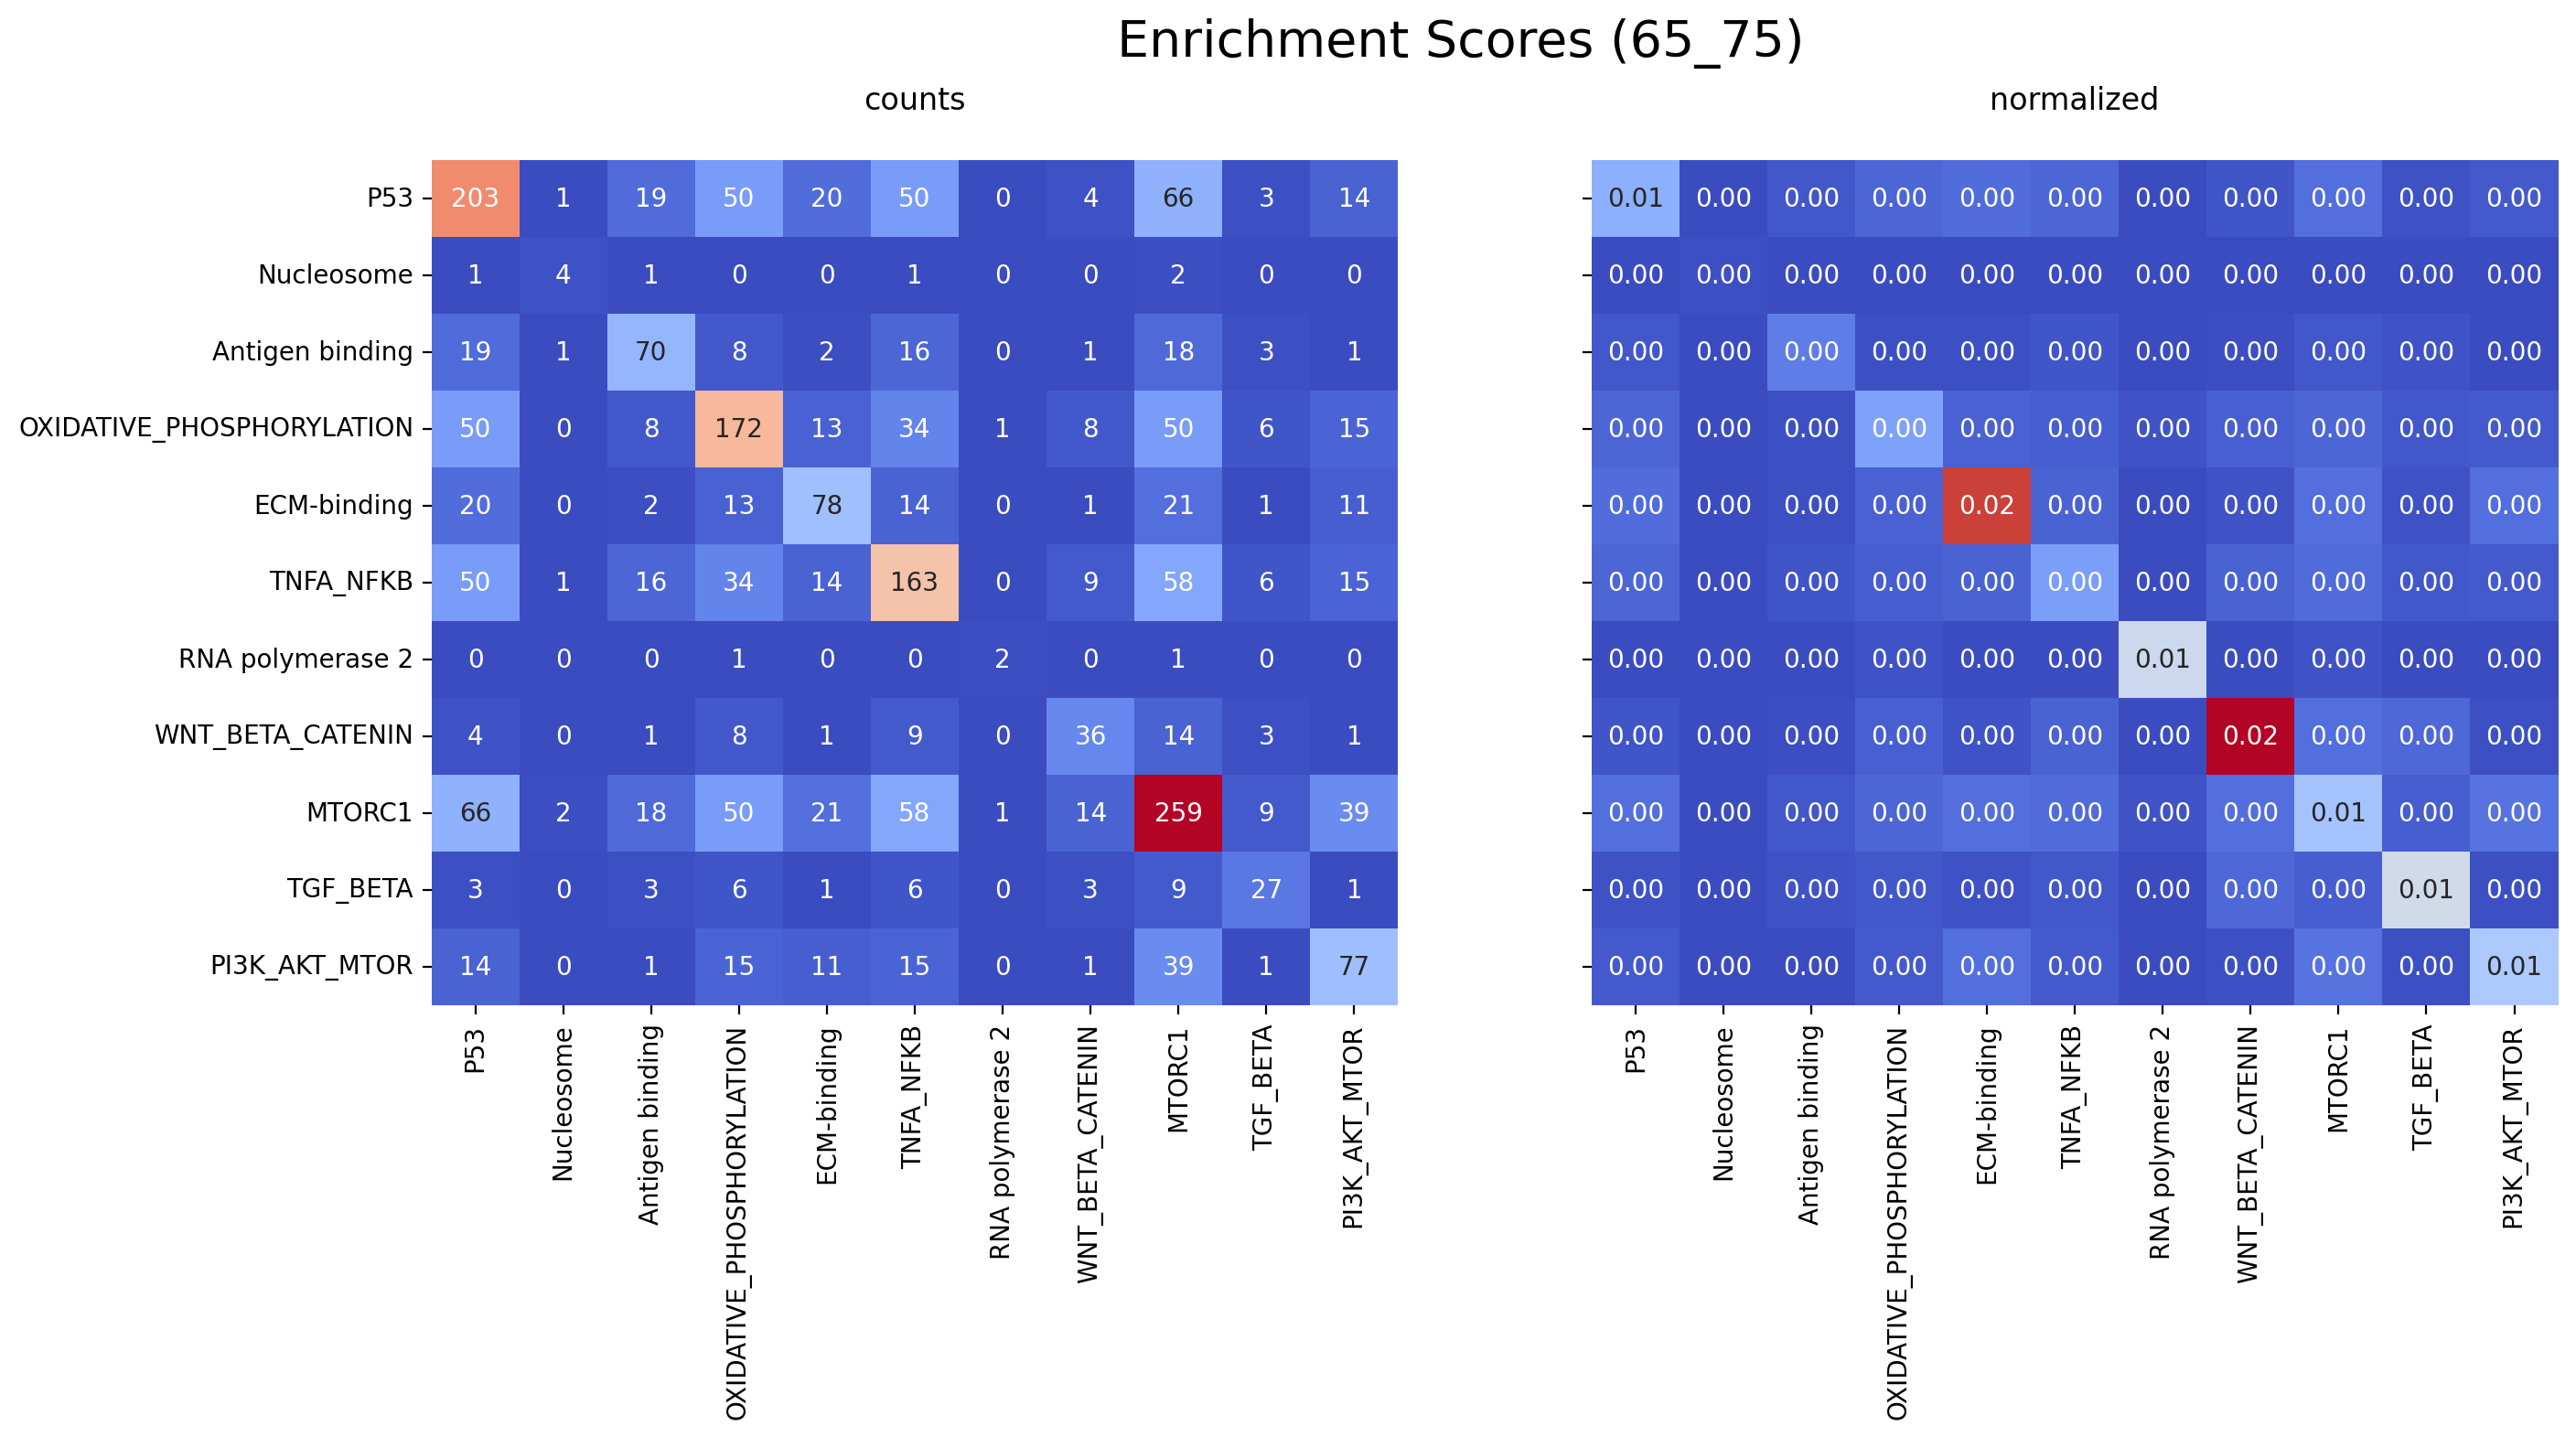

In [18]:
def extract_enrichment_scores(df):
    scores_mat = pd.DataFrame(np.zeros((n_pathway, n_pathway)), index=pathways, columns=pathways)
    i=0
    for g1, g2 in zip(df['g1'], df['g2']):
        pps = np.unique(pathway_df.loc[[g1, g2], 'pathway'].values)
        scores_mat.loc[pps,pps] = scores_mat.loc[pps,pps] + 1
    return scores_mat

if True: # enrichment score
    groups = common_links_df.groupby('age_group')

    pathways = list(set((pathway_df['pathway'].values)))
    n_pathway = len(pathways)

    # - determine the n possible links from each pathway combintation: to be used for normalization
    n_possible_links = pd.DataFrame(np.zeros((n_pathway, n_pathway)), index=pathways, columns=pathways)
    for p1 in pathways:
        for p2 in pathways:
            n_possible_links.loc[p1, p2] = len(genesets_dict[p1])*len(genesets_dict[p2])

    for age_group in ['45_54','65_75']:
        try:
            df_sig_a = groups.get_group(age_group)
        except:
            continue
        df_sig_a[['g1','g2']] = df_sig_a['link'].str.split('_', expand=True)
        df = df_sig_a
        # - get the enrichment scores 
        enrichment_scores = extract_enrichment_scores(df)
        enrichment_scores_n = enrichment_scores/n_possible_links

        # - plot    
        fig, axes = plt.subplots(1,2 , figsize=(15, 6), sharey=True, width_ratios=[1, 1])
        for i, (name, df) in enumerate(zip(['counts', 'normalized'], [enrichment_scores, enrichment_scores_n])):
            ax = axes[i]
            if name == 'normalized':
                fmt = '.02f'
            else:
                fmt = '.0f'
            sns.heatmap(df, annot=True, cmap='coolwarm', cbar=None,  ax=ax, fmt=fmt)
            ax.set_title(f'{name}', pad=20)
            ax.set_xlabel('')
            ax.set_ylabel('')
        fig.suptitle(f'Enrichment Scores ({age_group})', fontsize=20, y=1.01)

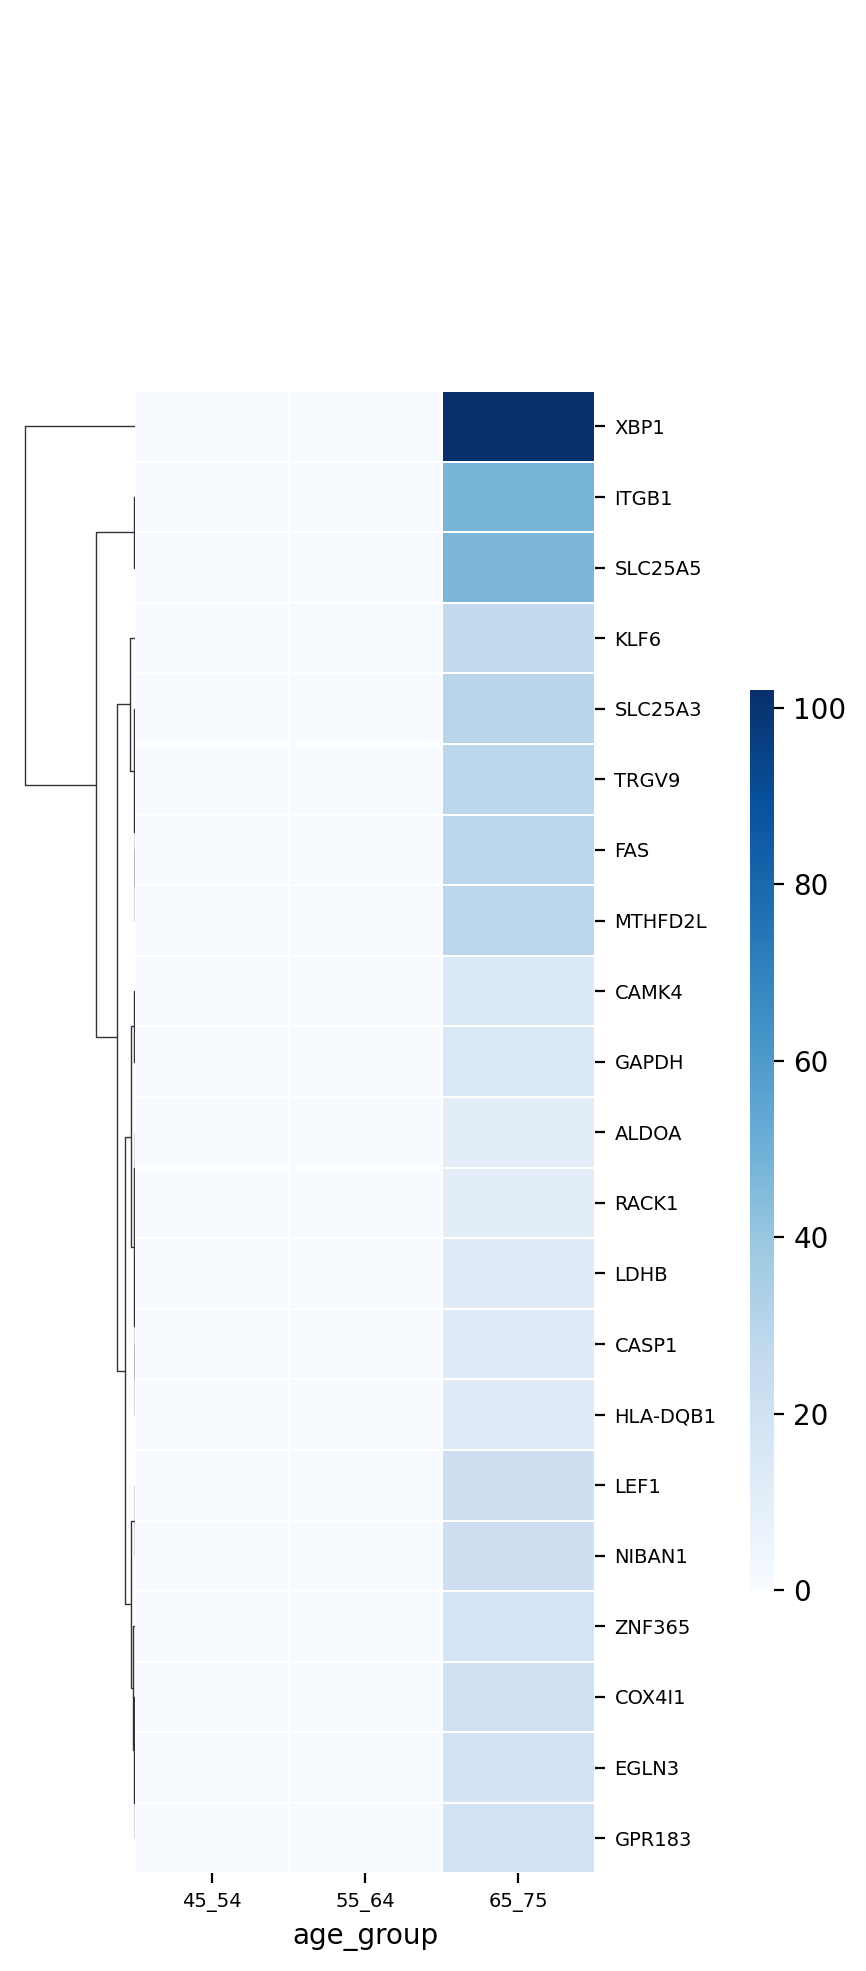

In [20]:
# - centrality degree dotplot, all ages, genes with degree > 10 in the target groups

if True: # plot_centrality_cluster()
    degree_t = 10

    groups = common_links_df.groupby('age_group')
    figsize=(4,10)
    target_groups=['45_54','65_75']

    # - heatmap
    def link_to_centrality(df):
        df['weight'] = 1
        gg_mat = link_to_matrix(df)
        degree = gg_mat.sum(axis=1)  
        return degree
    centrality_df = groups.apply(link_to_centrality).reset_index(level=0, name='degree').pivot(columns='age_group', values='degree').fillna(0)

    # filter 
    centrality_df = centrality_df[(centrality_df>degree_t)[target_groups].any(axis=1)]

    # plot
    g = sns.clustermap(centrality_df, cmap="Blues", row_cluster=True, col_cluster=False, 
                    figsize=figsize, linewidths=0.01, xticklabels=True, yticklabels=True, 
                    cbar_pos=(0.95, 0.2, 0.03, 0.45))
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=7)  
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=7)  
    plt.tight_layout()

In [7]:
if False: #heatmap  pathway association
    # - pathway association of sig links for age 65_75
    df_sig_a = groups.get_group('65_75')
    df_sig_a['weight'] = -np.log10(df_sig_a['pvalue'])

    g_g_mat = link_to_matrix(df_sig_a)
    heatmap_pathways(g_g_mat, pathway_df)

In [31]:
# contrast_results_dict['links_pvalues_vs_34_apr_spearman_bootstrapped_denoised']

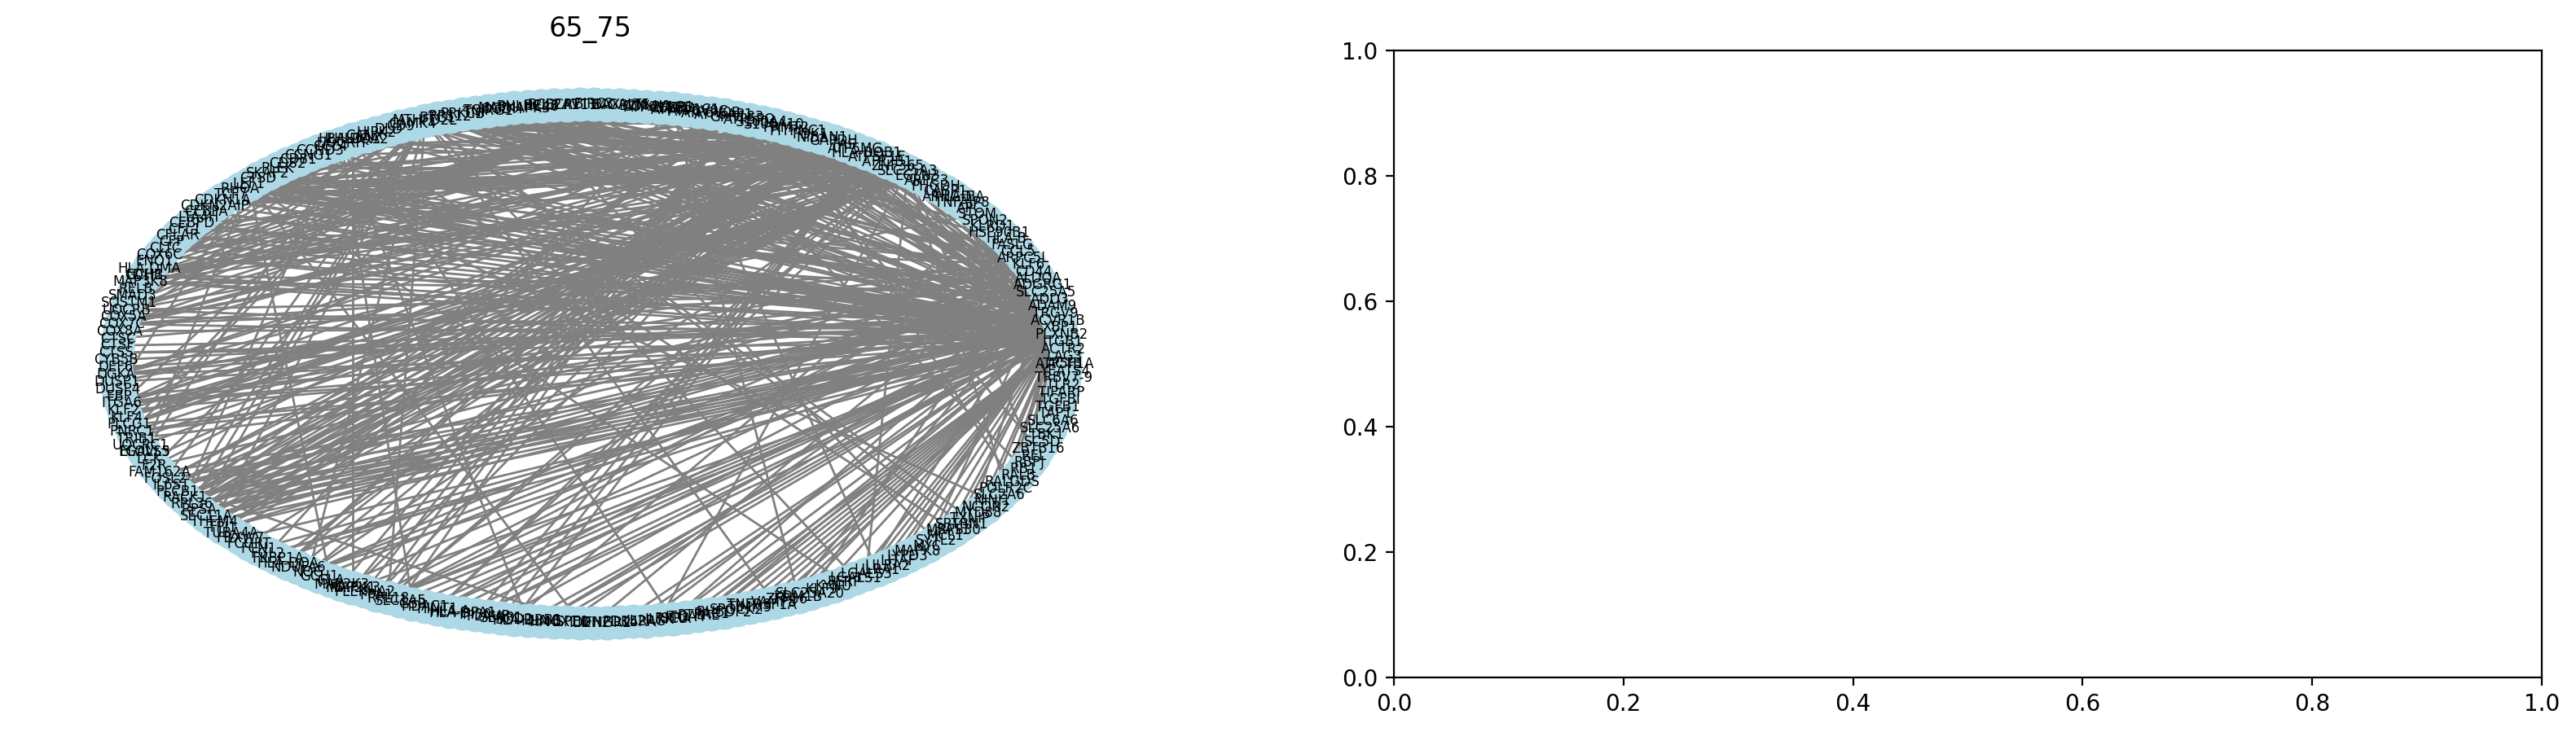

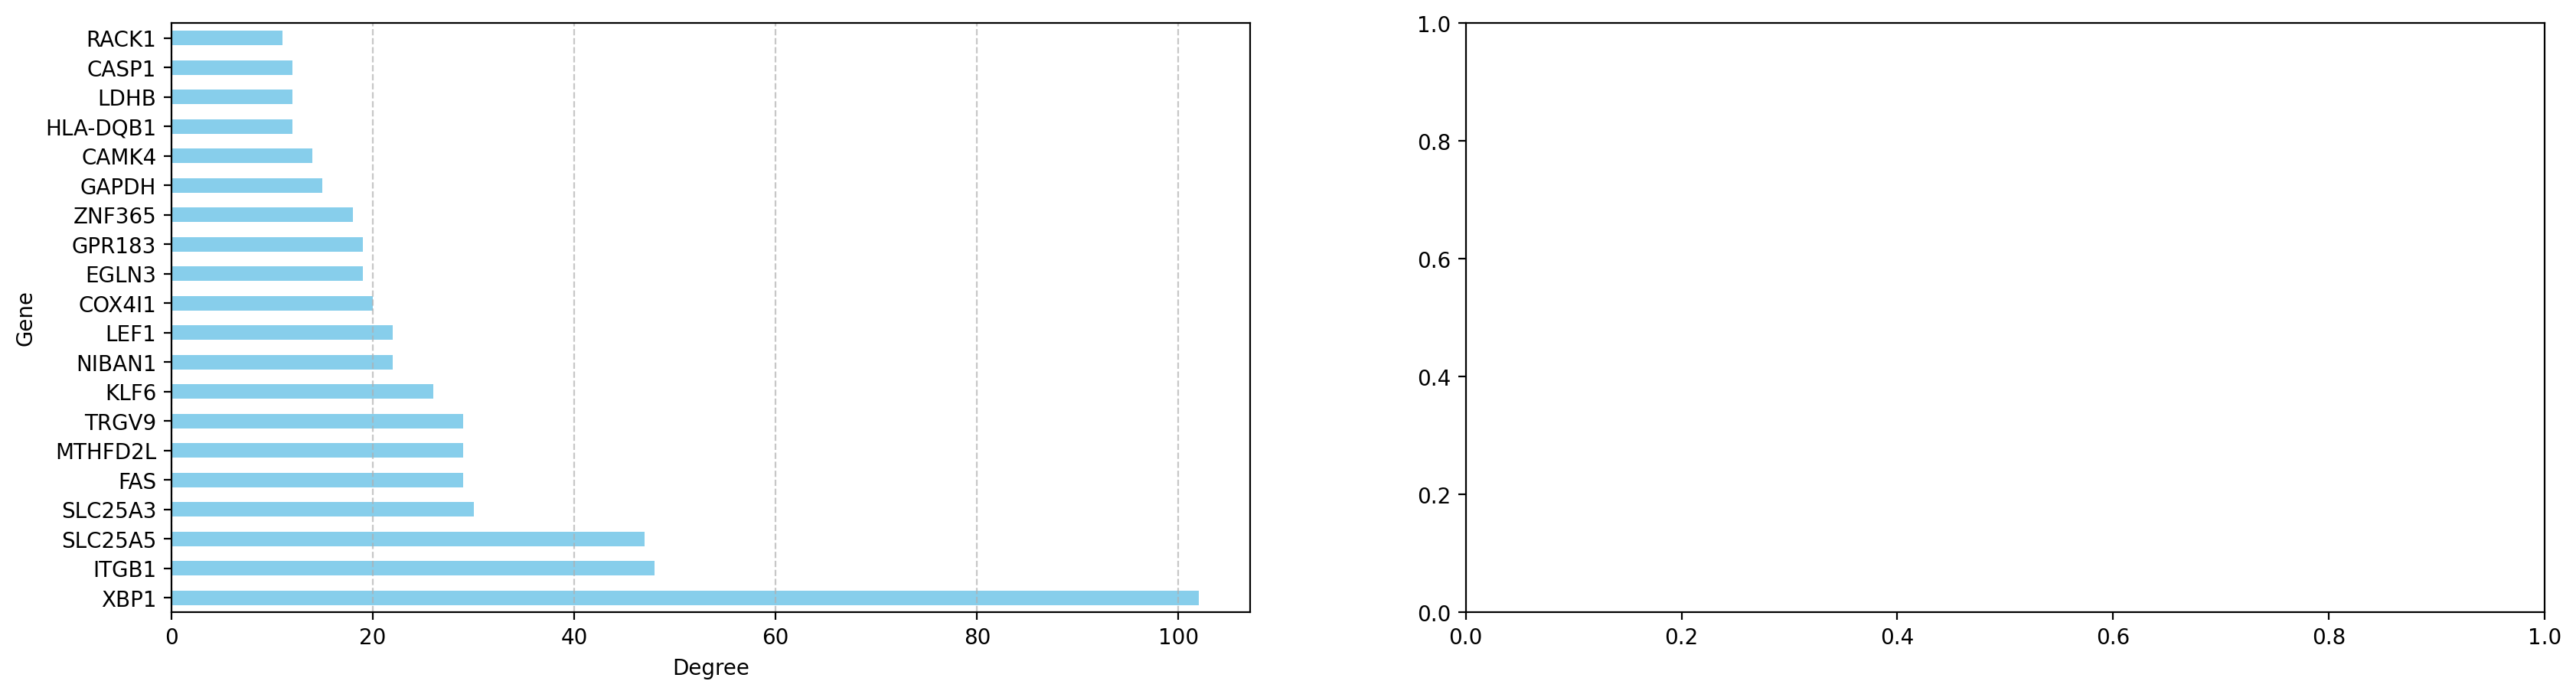

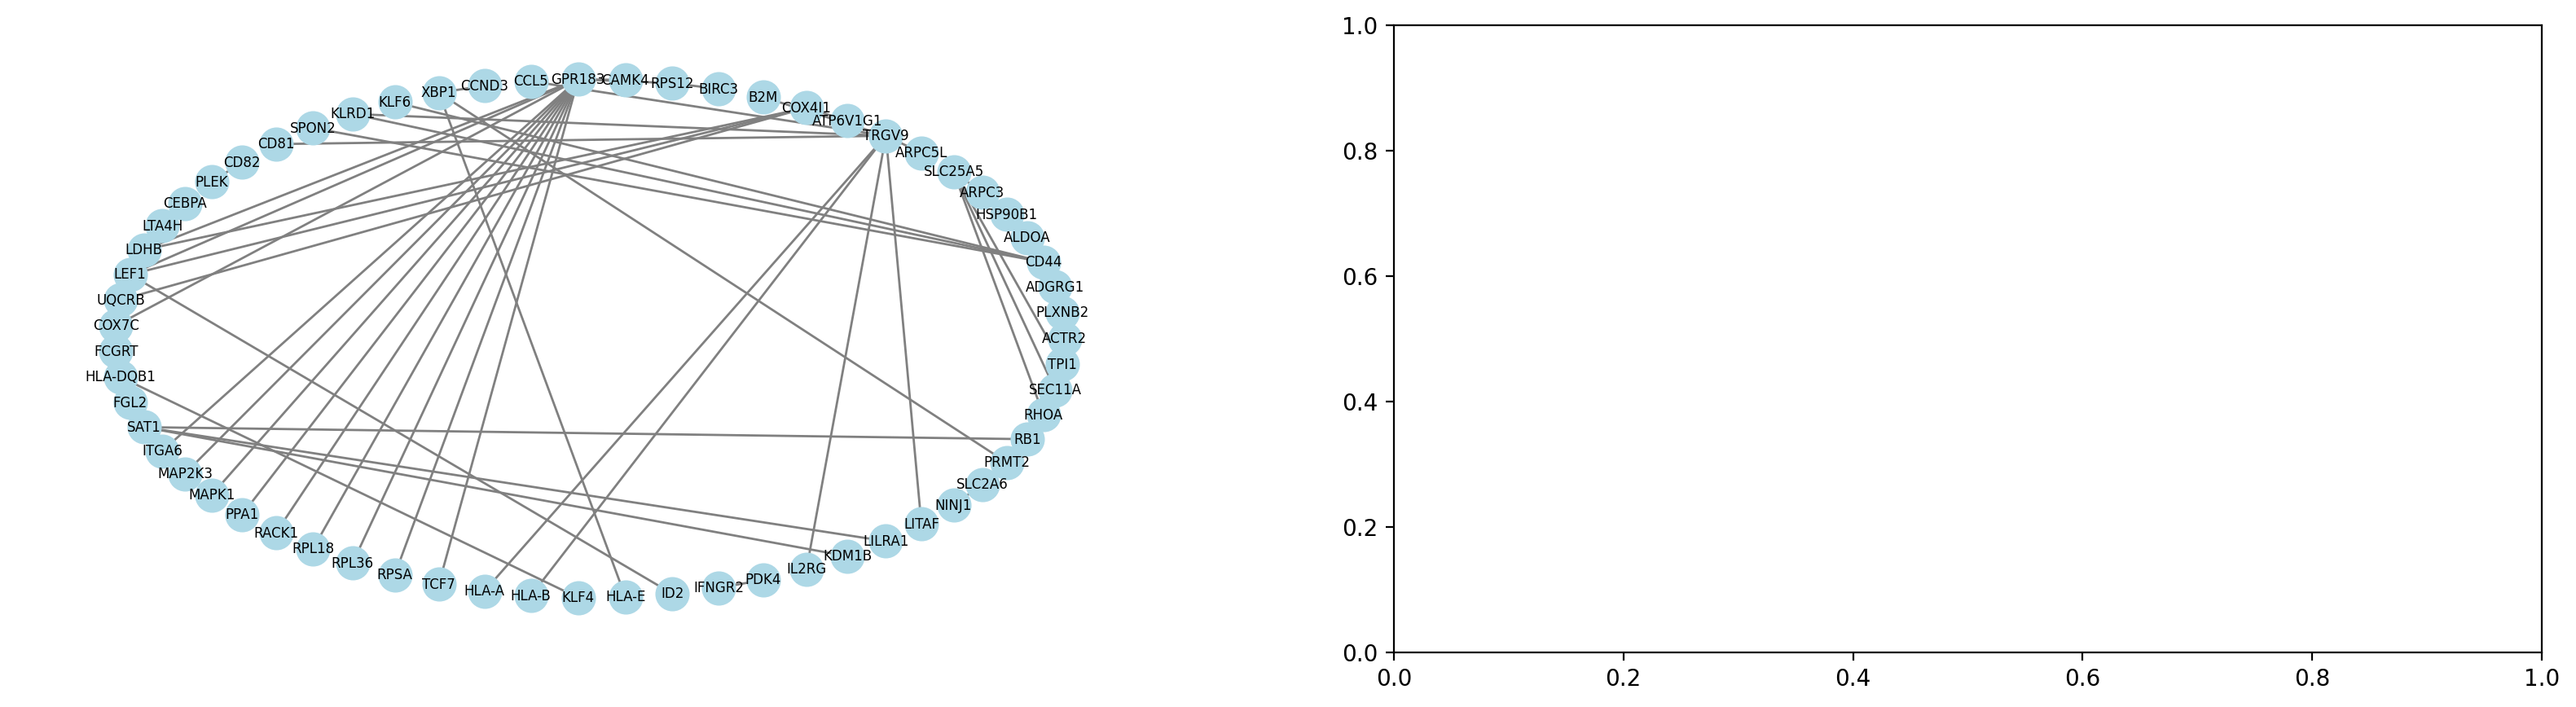

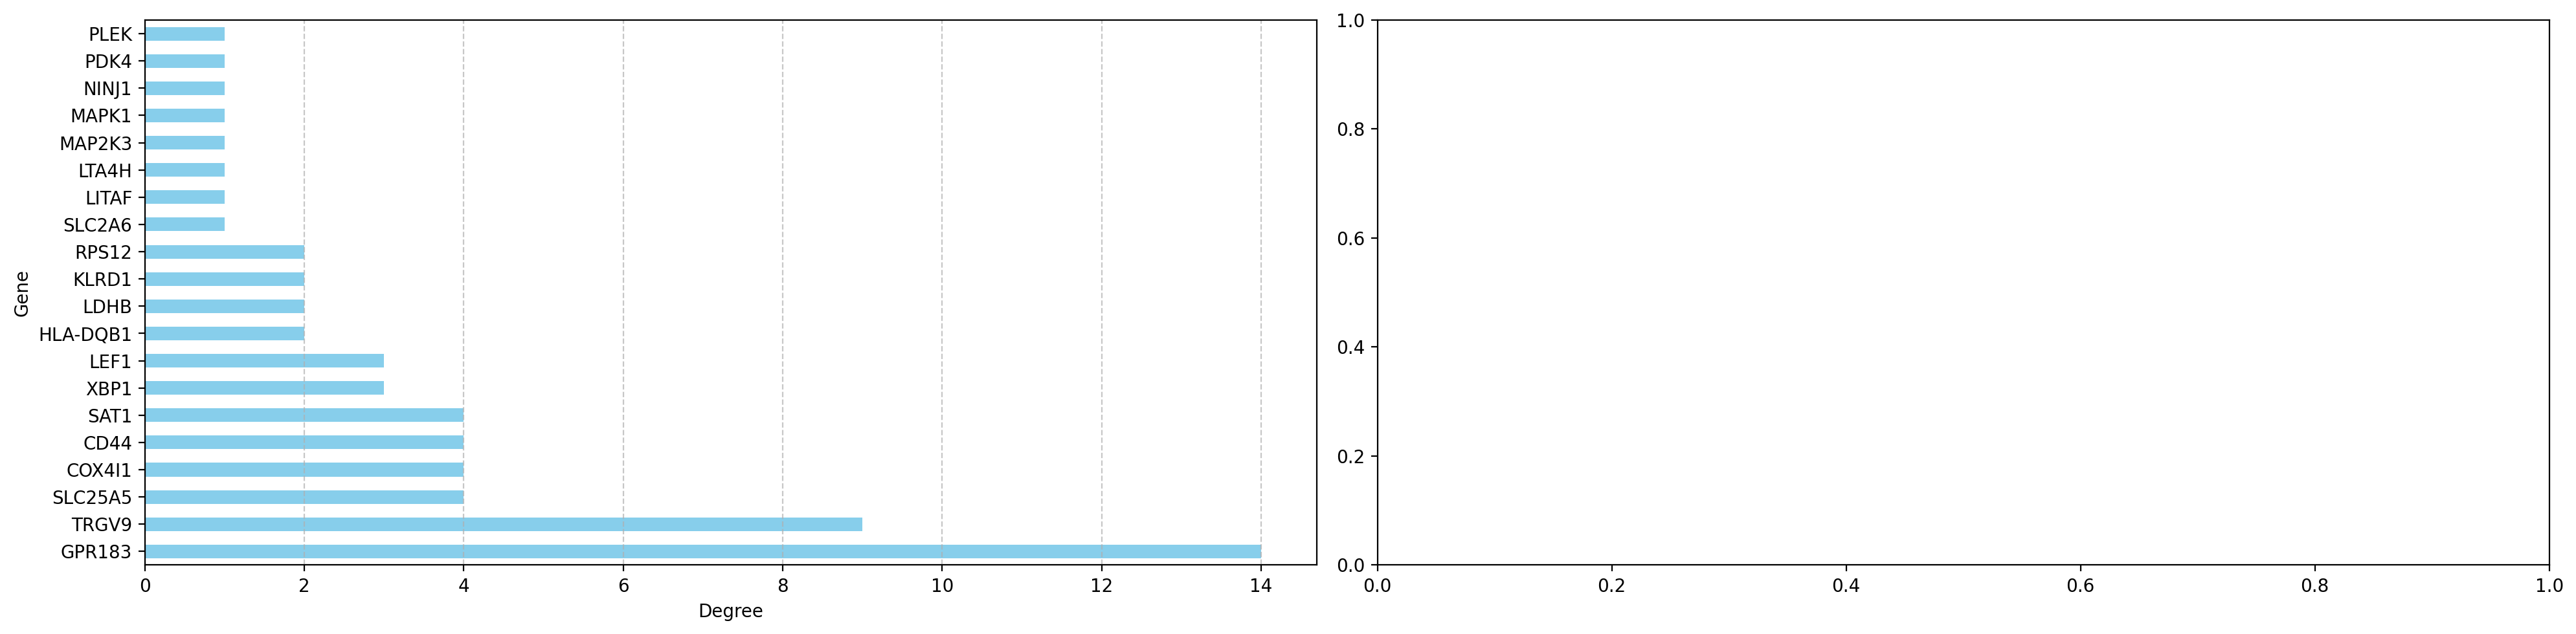

In [50]:
if True: # age group specific G plots and top degree fo 
    groups = common_links_df.groupby('age_group')
    age_groups_to_show =  ['45_54', '65_75']

    _, axes = plt.subplots(1, len(age_groups_to_show), figsize=(10*len(age_groups_to_show), 5))
    _, axes_ = plt.subplots(1, len(age_groups_to_show), figsize=(10*len(age_groups_to_show), 5))
    _, axes__ = plt.subplots(1, len(age_groups_to_show), figsize=(10*len(age_groups_to_show), 5))
    _, axes___ = plt.subplots(1, len(age_groups_to_show), figsize=(10*len(age_groups_to_show), 5))

    i_plot = 0 
    for age_group in age_groups_to_show:
        try:
            ax = axes[i_plot]
        except:
            ax = axes
        if age_group == '34-':
            continue
        # - plot all edges in G plot
        links_a = groups.get_group(age_group)
        G_plot(links_a, ax=axes[i_plot])
        ax.set_title(f'{age_group}') 

        # # - plot centrality
        links_a['weight'] = 1
        gg_mat = link_to_matrix(links_a)
        centrality_a = gg_mat.sum().sort_values(ascending=False)[:20]
        Exp_analysis.plot_centrality_barh(centrality_a, ax=axes_[i_plot])

        # - shortlist edges in G plot based on corr weights
        links_a_short = links_a[links_a['mean'].abs()>0.4]
        if len(links_a_short)<2: 
            continue
        G_plot(links_a_short, ax=axes__[i_plot])
        ax.set_title(f'{age_group}') 

        # - plot centrality for shortlist
        links_a_short['weight'] = 1
        gg_mat = link_to_matrix(links_a_short)
        centrality_a = gg_mat.sum().sort_values(ascending=False)[:20]
        Exp_analysis.plot_centrality_barh(centrality_a, ax=axes___[i_plot])

        i_plot+=1

        plt.tight_layout()

# Regression analysis

In [160]:
aaa

NameError: name 'aaa' is not defined